# ML&AI Project: Predicting London Bike-Sharing Demand



In [1]:
# Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
# Loading the dataset

df = pd.read_csv('File2_combined_journey_data_03162026.csv')

print('Raw columns:', df.columns.tolist())
print(f'Raw records: {len(df):,}')
df.head(3)

Raw columns: ['Number', 'Start date', 'Start station number', 'Start station', 'End date', 'End station number', 'End station', 'Bike number', 'Bike model', 'Total duration', 'Total duration (ms)', 'Source URL']
Raw records: 26,386,749


,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms),Source URL
0,127702739,2023-01-01 23:58,3425,"Northington Street , Holborn",2023-01-02 00:04,1229,"High Holborn , Covent Garden",35465.0,CLASSIC,6m 30s,390467.0,https://cycling.data.tfl.gov.uk/usage-stats/35...
1,127702740,2023-01-01 23:58,3499,"Prince Consort Road, Knightsbridge",2023-01-02 00:06,200060,"Drayton Gardens, West Chelsea",55526.0,CLASSIC,8m 9s,489880.0,https://cycling.data.tfl.gov.uk/usage-stats/35...
2,127702737,2023-01-01 23:56,300092,"Hertford Road, De Beauvoir Town",2023-01-02 00:05,3500,"Baldwin Street, St. Luke's",57152.0,CLASSIC,8m 50s,530606.0,https://cycling.data.tfl.gov.uk/usage-stats/35...


Data Formatting

In [3]:
# Since data consists different date formats, we will parse dates with dayfirst=True and coerce errors to NaT
df['Start date raw'] = df['Start date']

# Parse mixed formats
df['Start date'] = pd.to_datetime(
    df['Start date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

print("Invalid dates:", df['Start date'].isna().sum())

# Drop rows that could not be parsed
df = df.dropna(subset=['Start date']).copy()

# We normalize the date to remove time component and group by date for daily demand
df['Date'] = df['Start date'].dt.normalize()

daily = (
    df.groupby('Date')
      .size()
      .reset_index(name='demand')
      .sort_values('Date')
      .reset_index(drop=True)
)

print(f"Daily records: {len(daily)}")
print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Demand range: {daily['demand'].min():,} to {daily['demand'].max():,}")

Invalid dates: 0
Daily records: 1102
Date range: 2022-12-26 to 2025-12-31
Demand range: 188 to 45,824


In [4]:
# We remove outliers with demand < 500 as they are likely data errors 
outliers = daily[daily['demand'] < 500]
print(f'Outlier days (demand < 500): {len(outliers)}')
if len(outliers) > 0:
    print(outliers[['Date','demand']].to_string())

daily = daily[daily['demand'] >= 500].copy().reset_index(drop=True)
print(f'\nClean dataset: {len(daily)} days')

Outlier days (demand < 500): 1
          Date  demand
953 2025-08-05     188

Clean dataset: 1101 days


Time Series Data - Splitting week,month,season

In [5]:
# we divided the dates month, day of week, weekend, season, day of year and year as features for the model
daily['month']       = daily['Date'].dt.month
daily['day_of_week'] = daily['Date'].dt.dayofweek         
daily['is_weekend']  = (daily['day_of_week'] >= 5).astype(int)
daily['season']      = daily['month'].map(
    {12:1, 1:1, 2:1,   # Winter
      3:2,  4:2, 5:2,   # Spring
      6:3,  7:3, 8:3,   # Summer
      9:4, 10:4, 11:4}  # Autumn
)
daily['day_of_year'] = daily['Date'].dt.dayofyear
daily['year']        = daily['Date'].dt.year

FEATURES = ['month','day_of_week','is_weekend','season','day_of_year','year']
print('Features created:', FEATURES)
daily[FEATURES + ['demand']].describe().round(1)

Features created: ['month', 'day_of_week', 'is_weekend', 'season', 'day_of_year', 'year']


,month,day_of_week,is_weekend,season,day_of_year,year,demand
count,1101.0,1101.0,1101.0,1101.0,1101.0,1101.0,1101.0
mean,6.6,3.0,0.3,2.5,184.1,2024.0,23966.0
std,3.5,2.0,0.5,1.1,106.1,0.8,6274.7
min,1.0,0.0,0.0,1.0,1.0,2022.0,5404.0
25%,4.0,1.0,0.0,1.0,92.0,2023.0,20392.0
50%,7.0,3.0,0.0,2.0,184.0,2024.0,24668.0
75%,10.0,5.0,1.0,3.0,276.0,2025.0,28638.0
max,12.0,6.0,1.0,4.0,366.0,2025.0,45824.0


Spllitting test and train datasets

In [26]:
# We spllit the data into train and test sets with 80% for training and 20% for testing. 
# Because this is time-series data, we will use the first 80% of the days for training 
# and the last 20% for testing

split_idx = int(0.8 * len(daily))
train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

X_train = train[FEATURES].values
y_train = train['demand'].values
X_test  = test[FEATURES].values
y_test  = test['demand'].values

# Time-series cross-validation (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

print(f'Train: {len(train)} days  ({train.Date.min().date()} to {train.Date.max().date()})')
print(f'Test:  {len(test)}  days  ({test.Date.min().date()}  to {test.Date.max().date()})')

Train: 880 days  (2022-12-26 to 2025-05-23)
Test:  221  days  (2025-05-24  to 2025-12-31)


Plots for visualization

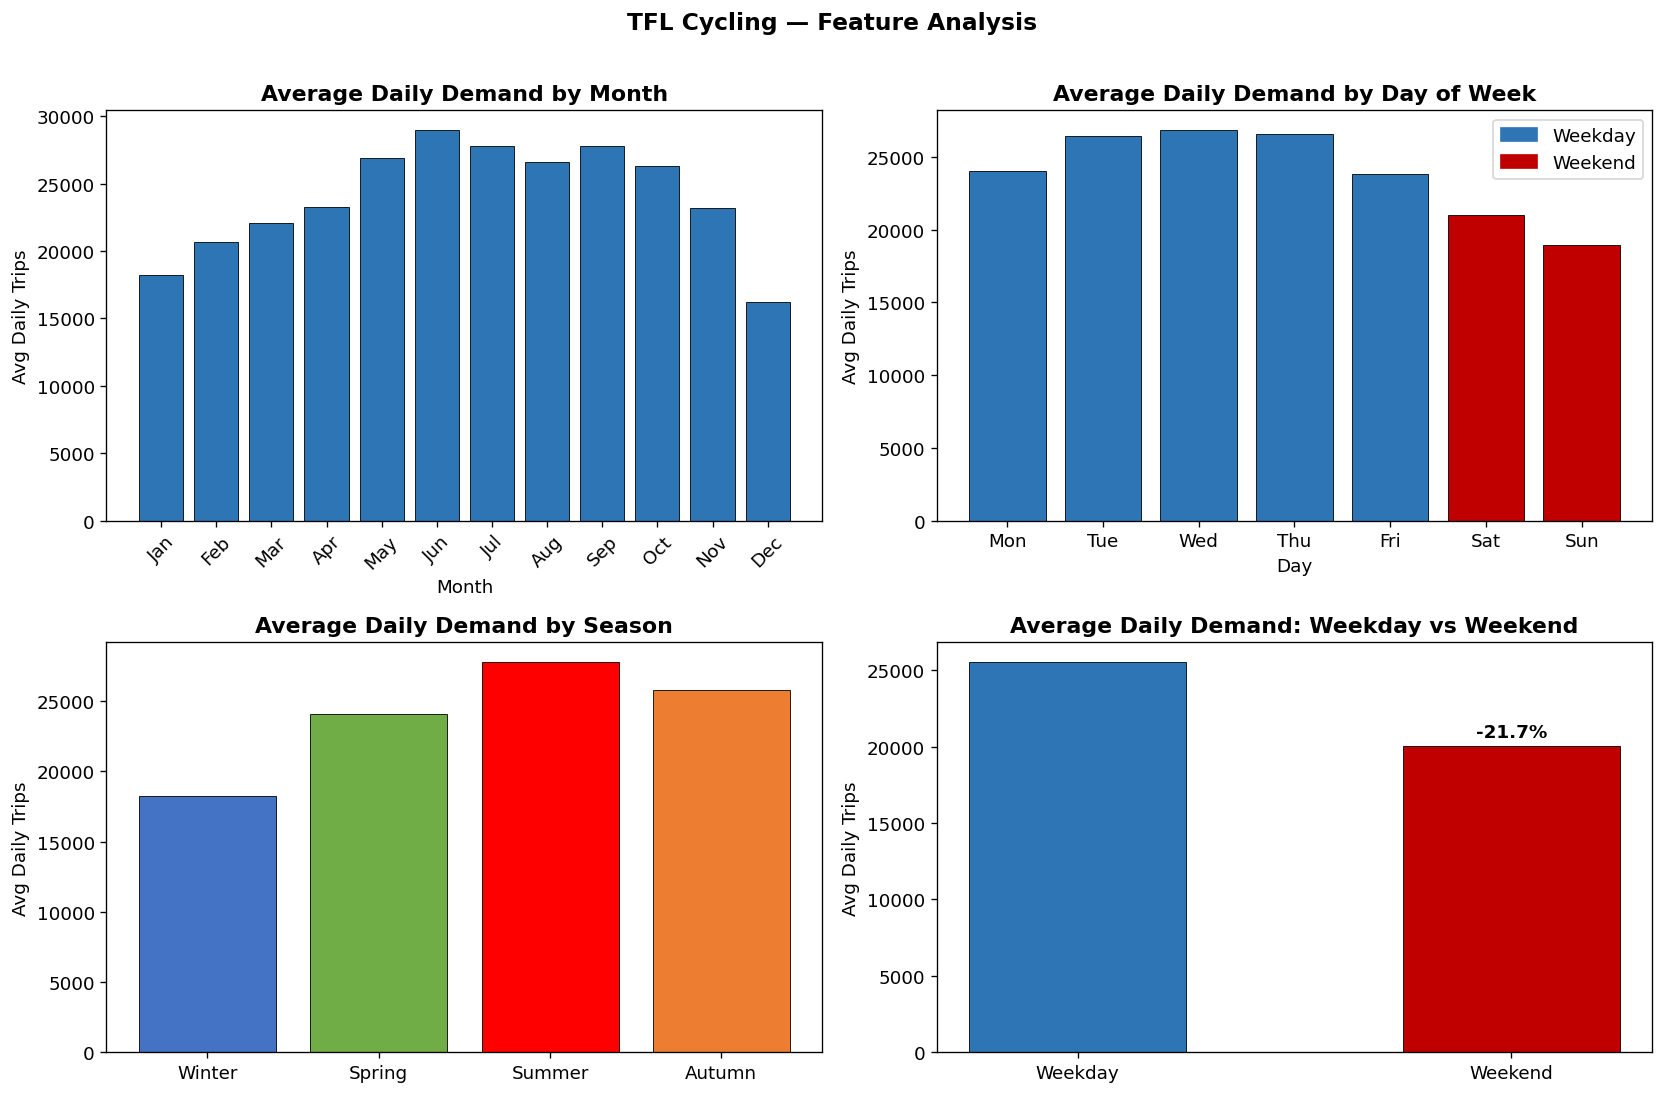

Saved: fig_feature_analysis.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

BLUE='#2E75B6'  

# Monthly plot
monthly = daily.groupby('month')['demand'].mean()
axes[0,0].bar(monthly.index, monthly.values, color=BLUE, edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Average Daily Demand by Month', fontweight='bold')
axes[0,0].set_xlabel('Month'); axes[0,0].set_ylabel('Avg Daily Trips')
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# Day of week
dow = daily.groupby('day_of_week')['demand'].mean()
colors_dow = ['#2E75B6']*5 + ['#C00000','#C00000']
axes[0,1].bar(dow.index, dow.values, color=colors_dow, edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Average Daily Demand by Day of Week', fontweight='bold')
axes[0,1].set_xlabel('Day'); axes[0,1].set_ylabel('Avg Daily Trips')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
blue_p  = mpatches.Patch(color='#2E75B6', label='Weekday')
red_p   = mpatches.Patch(color='#C00000', label='Weekend')
axes[0,1].legend(handles=[blue_p, red_p])

# Season
season_labels = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Autumn'}
season_avg = daily.groupby('season')['demand'].mean()
season_colors = ['#4472C4','#70AD47','#FF0000','#ED7D31']
axes[1,0].bar([season_labels[s] for s in season_avg.index],
               season_avg.values, color=season_colors, edgecolor='black', linewidth=0.5)
axes[1,0].set_title('Average Daily Demand by Season', fontweight='bold')
axes[1,0].set_ylabel('Avg Daily Trips')

# Weekend vs weekday
wknd = daily.groupby('is_weekend')['demand'].mean()
axes[1,1].bar(['Weekday','Weekend'], wknd.values,
               color=['#2E75B6','#C00000'], edgecolor='black', linewidth=0.5, width=0.5)
axes[1,1].set_title('Average Daily Demand: Weekday vs Weekend', fontweight='bold')
axes[1,1].set_ylabel('Avg Daily Trips')
pct_diff = (wknd[1]-wknd[0])/wknd[0]*100
axes[1,1].annotate(f'{pct_diff:+.1f}%', xy=(1, wknd[1]),
                    xytext=(1, wknd[1]*1.03), ha='center', fontweight='bold')

plt.suptitle('TFL Cycling — Feature Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_feature_analysis.png')

Defining metrics to compare different models

In [8]:
# To compaare different models, we will use MAE, RMSE and MAPE as metrics. 
# We will also report 5-fold CV MAE for reference.
def compute_metrics(name, y_true, y_pred, cv_mae=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    cv_str = f'{cv_mae:,.0f}' if cv_mae else 'N/A'
    print(f'{name}')
    print(f'  MAE : {mae:>10,.1f}')
    print(f'  RMSE: {rmse:>10,.1f}')
    print(f'  MAPE: {mape:>10.1f}%')
    print(f'  CV MAE (5-fold): {cv_str}')
    print()
    return {'name':name, 'mae':mae, 'rmse':rmse, 'mape':mape, 'cv_mae':cv_mae}

results = []   # collect all results for comparison table

Linear Regression

In [9]:
# We took the first model as Linear Regression to set a baseline 
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# CV MAE
lr_cv = -cross_val_score(LinearRegression(), X_train, y_train,
                          cv=tscv, scoring='neg_mean_absolute_error').mean()

res_lr = compute_metrics('Linear Regression', y_test, lr_pred, lr_cv)
results.append(res_lr)

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})
print('Coefficients:')
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

Linear Regression
  MAE :    3,788.7
  RMSE:    4,807.2
  MAPE:       17.7%
  CV MAE (5-fold): 6,805

Coefficients:
    Feature  Coefficient
     season  3592.964264
       year   970.694147
day_of_year   -10.943771
      month   -92.703005
day_of_week  -112.055940
 is_weekend -5005.554990


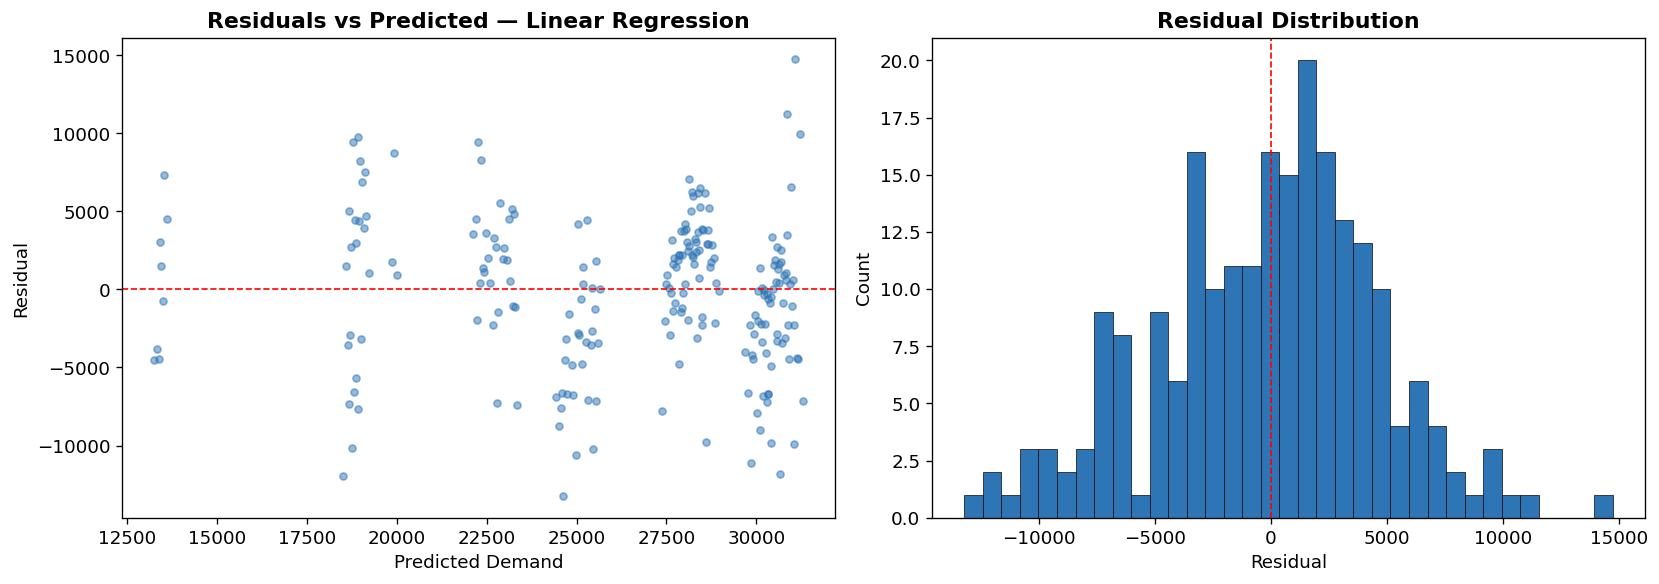

Saved: fig_lr_residuals.png


In [10]:
# we compute the residuals and plot them to check for patterns that might indicate issues with the model fit
residuals = y_test - lr_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(lr_pred, residuals, alpha=0.5, s=18, color=BLUE)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted — Linear Regression', fontweight='bold')
axes[0].set_xlabel('Predicted Demand'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=35, color=BLUE, edgecolor='black', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_lr_residuals.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_lr_residuals.png')

Regularization Lasso and Ridge

In [11]:
# We applied regularization with Lasso to see if it can improve performance
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    cv=tscv, scoring='neg_mean_absolute_error'
)
lasso_grid.fit(X_train, y_train)
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test)
lasso_cv   = -lasso_grid.best_score_

print(f'Best Lasso alpha: {lasso_grid.best_params_["alpha"]}')
print('Lasso coefficients:')
for f, c in zip(FEATURES, lasso_best.coef_):
    print(f'  {f:<15} {c:>10.2f}  {"(zeroed)" if abs(c)<0.01 else ""}')
print()

res_lasso = compute_metrics('Lasso', y_test, lasso_pred, lasso_cv)
results.append(res_lasso)

Best Lasso alpha: 100.0
Lasso coefficients:
  month                -0.00  (zeroed)
  day_of_week        -277.52  
  is_weekend        -3934.81  
  season             3452.89  
  day_of_year         -13.55  
  year                759.40  

Lasso
  MAE :    3,818.4
  RMSE:    4,795.1
  MAPE:       17.6%
  CV MAE (5-fold): 4,171



In [12]:

# To compare regularization with Ridge, we will also apply Ridge regression and see if it can improve performance
ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    cv=tscv, scoring='neg_mean_absolute_error'
)
ridge_grid.fit(X_train, y_train)
ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test)
ridge_cv   = -ridge_grid.best_score_

print(f'Best Ridge alpha: {ridge_grid.best_params_["alpha"]}')
res_ridge = compute_metrics('Ridge', y_test, ridge_pred, ridge_cv)
results.append(res_ridge)

Best Ridge alpha: 10.0
Ridge
  MAE :    3,792.0
  RMSE:    4,804.5
  MAPE:       17.7%
  CV MAE (5-fold): 4,403



KNN Regression

In [13]:

# Next, we will apply K-Nearest Neighbors regression 
# We will scale the features before applying KNN since it is sensitive to feature scales.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    {'n_neighbors': [3, 5, 7, 10, 15, 20, 30]},
    cv=tscv, scoring='neg_mean_absolute_error'
)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test_scaled)
knn_cv   = -knn_grid.best_score_

print(f'Best K: {knn_grid.best_params_["n_neighbors"]}')
res_knn = compute_metrics('KNN', y_test, knn_pred, knn_cv)
results.append(res_knn)

Best K: 10
KNN
  MAE :    3,063.7
  RMSE:    4,085.0
  MAPE:       14.1%
  CV MAE (5-fold): 3,640



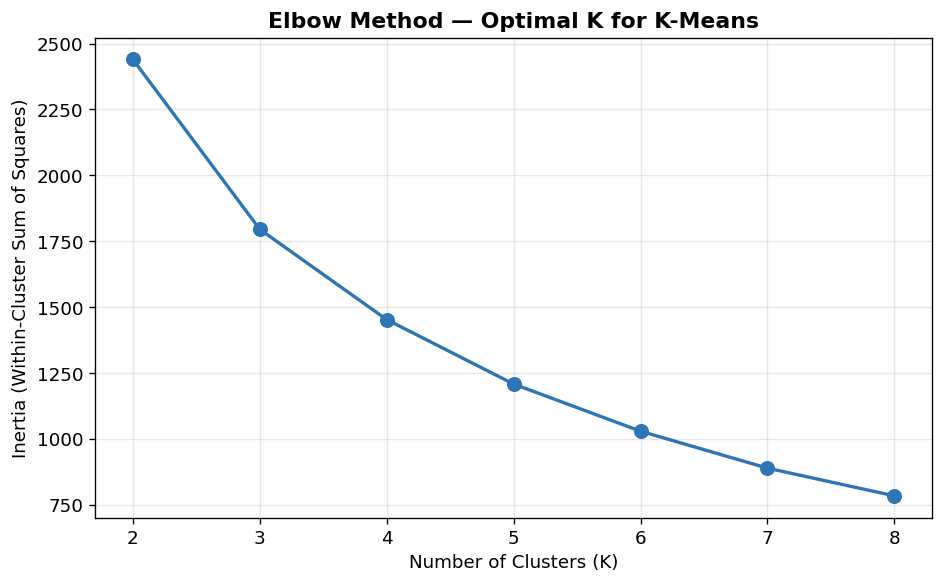

Saved: fig_kmeans_elbow.png


In [14]:

# to decide optimal K, we use the Elbow Method

cluster_features = ['demand','month','is_weekend','day_of_week']
X_cluster = StandardScaler().fit_transform(daily[cluster_features])

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, 'o-', color=BLUE, linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal K for K-Means', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_kmeans_elbow.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_kmeans_elbow.png')

In [15]:

# Optimal K looks like 3 based on the elbow plot

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
daily['cluster'] = km_final.fit_predict(X_cluster)

# Label clusters by mean demand (0=Low, 1=Mid, 2=High)
cluster_means = daily.groupby('cluster')['demand'].mean().sort_values()
cluster_label_map = {old: new for new, old in enumerate(cluster_means.index)}
daily['cluster_label'] = daily['cluster'].map(cluster_label_map)
label_names = {0:'Low', 1:'Mid', 2:'High'}
daily['cluster_name'] = daily['cluster_label'].map(label_names)

print('Cluster summary:')
print(daily.groupby('cluster_name')[['demand','month','is_weekend']]
        .agg({'demand':['mean','count'],'month':'mean','is_weekend':'mean'})
        .round(2))

Cluster summary:
                demand       month is_weekend
                  mean count  mean       mean
cluster_name                                 
High          27342.17   498  8.71        0.0
Low           19963.71   315  6.59        1.0
Mid           22505.52   288  2.77        0.0


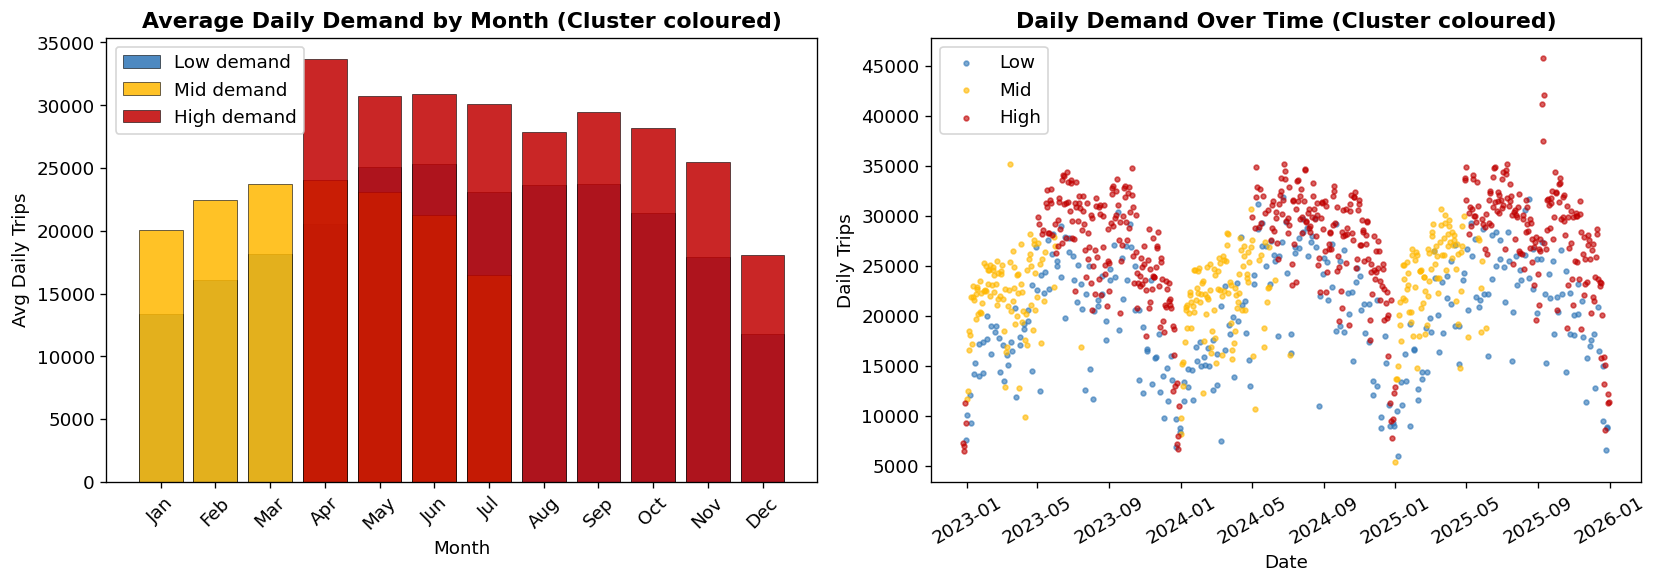

Saved: fig_cluster_business.png


In [16]:

cluster_colors = {'Low':'#2E75B6', 'Mid':'#FFB800', 'High':'#C00000'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Demand by month with cluster coloring
monthly_cluster = daily.groupby(['month','cluster_name'])['demand'].mean().unstack()
for cname, color in cluster_colors.items():
    if cname in monthly_cluster.columns:
        axes[0].bar(monthly_cluster.index, monthly_cluster[cname],
                     label=f'{cname} demand', color=color, alpha=0.85, edgecolor='black', linewidth=0.4)
axes[0].set_title('Average Daily Demand by Month (Cluster coloured)', fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Avg Daily Trips')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].legend()

# Time-series with cluster band
for cname, color in cluster_colors.items():
    mask = daily['cluster_name'] == cname
    axes[1].scatter(daily.loc[mask,'Date'], daily.loc[mask,'demand'],
                     s=8, color=color, alpha=0.6, label=cname)
axes[1].set_title('Daily Demand Over Time (Cluster coloured)', fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Daily Trips')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_cluster_business.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_cluster_business.png')

Random Forest

In [17]:

# Our next model is Random Forest 
# We will tune the number of trees, max depth and minimum samples per leaf to find the best configuration.

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [100, 200],
     'max_depth':    [10, 20, None],
     'min_samples_leaf': [2, 5]},
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_cv   = -rf_grid.best_score_

print(f'Best RF params: {rf_grid.best_params_}')
res_rf = compute_metrics('Random Forest', y_test, rf_pred, rf_cv)
results.append(res_rf)

Best RF params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest
  MAE :    2,685.9
  RMSE:    3,608.0
  MAPE:       11.5%
  CV MAE (5-fold): 3,768



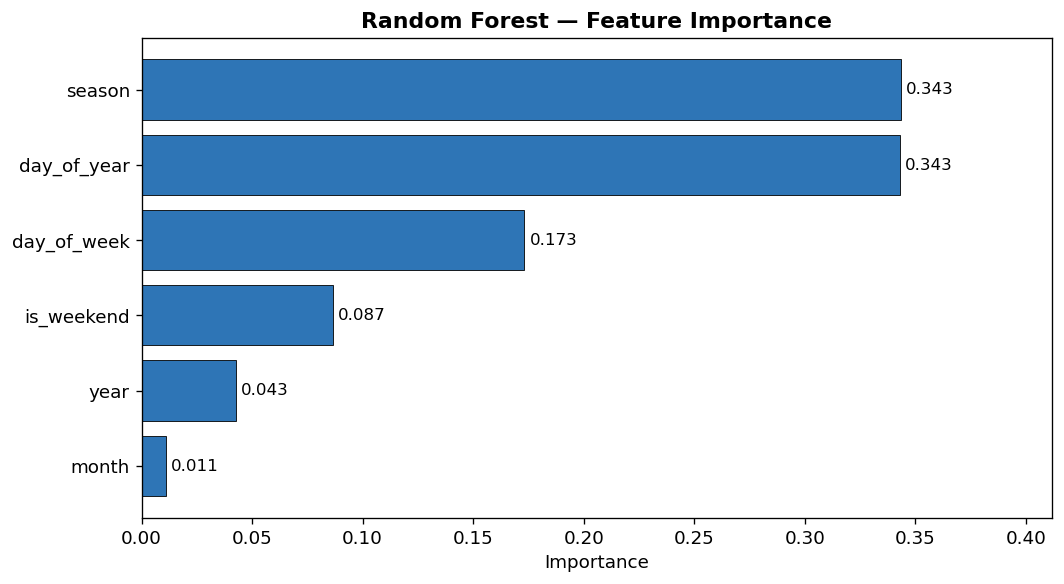

Saved: fig_rf_feature_importance.png


In [18]:
# We computed the importance of each variable
importances = rf_best.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
                color=BLUE, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
ax.set_xlim(0, fi_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_rf_feature_importance.png')

Gradient Boosting

In [19]:

# Finally, we will apply Gradient Boosting to see if it can further improve performance.

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_cv = -cross_val_score(gb, X_train, y_train,
                          cv=tscv, scoring='neg_mean_absolute_error').mean()

res_gb = compute_metrics('Gradient Boosting', y_test, gb_pred, gb_cv)
results.append(res_gb)

Gradient Boosting
  MAE :    3,500.7
  RMSE:    4,506.5
  MAPE:       15.5%
  CV MAE (5-fold): 4,197



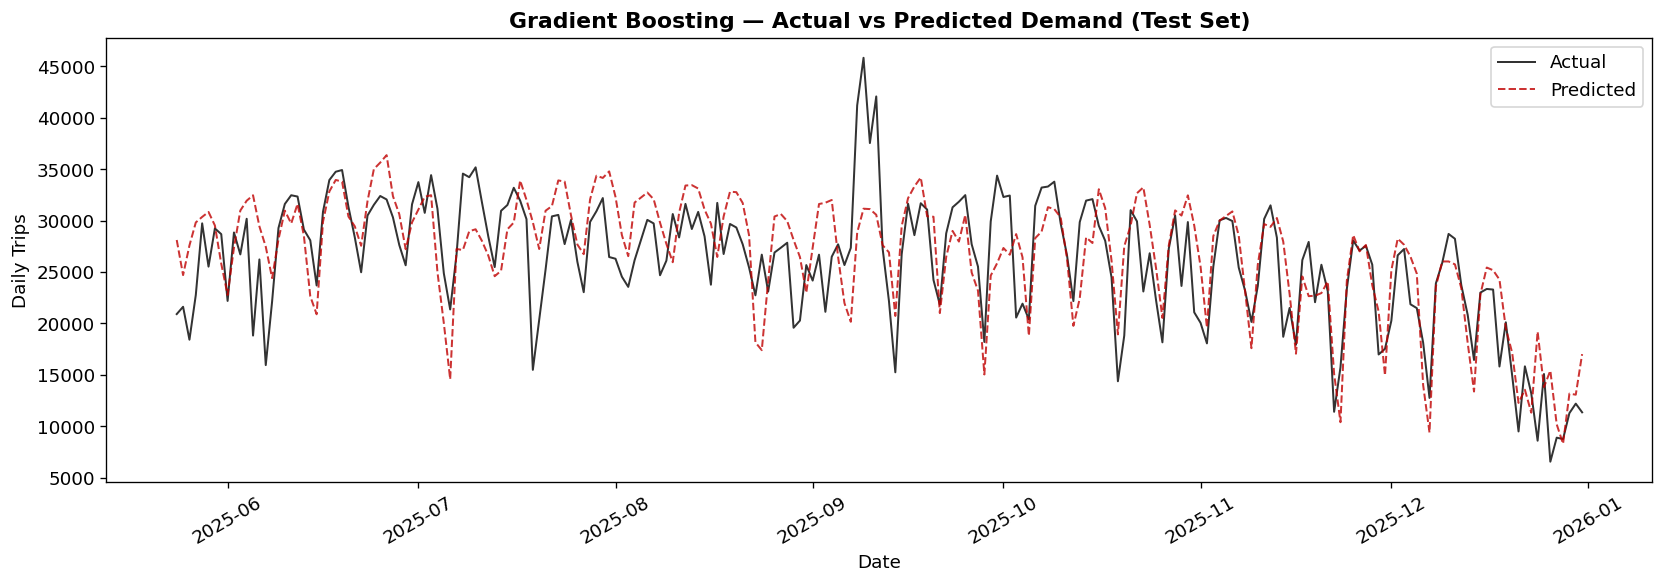

Saved: fig_gb_actual_vs_predicted.png


In [20]:
# We will compare the actual vs predicted demand for the test set 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['Date'].values, y_test,  label='Actual',    color='black',  linewidth=1.2, alpha=0.8)
ax.plot(test['Date'].values, gb_pred, label='Predicted', color='#C00000', linewidth=1.2, alpha=0.8, linestyle='--')
ax.set_title('Gradient Boosting — Actual vs Predicted Demand (Test Set)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Daily Trips')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig_gb_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_gb_actual_vs_predicted.png')

In [21]:

# to see which model performed best, we will create a comparison table with all the metrics for each model.

comp_df = pd.DataFrame(results)
comp_df['mae']  = comp_df['mae'].map('{:,.0f}'.format)
comp_df['rmse'] = comp_df['rmse'].map('{:,.0f}'.format)
comp_df['mape'] = comp_df['mape'].map('{:.1f}%'.format)
comp_df['cv_mae'] = comp_df['cv_mae'].apply(
    lambda x: f'{x:,.0f}' if pd.notna(x) else 'N/A')
comp_df.columns = ['Model','MAE','RMSE','MAPE','CV MAE (5-fold)']


print('MODEL COMPARISON TABLE')

print(comp_df.to_string(index=False))


MODEL COMPARISON TABLE
            Model   MAE  RMSE  MAPE CV MAE (5-fold)
Linear Regression 3,789 4,807 17.7%           6,805
            Lasso 3,818 4,795 17.6%           4,171
            Ridge 3,792 4,804 17.7%           4,403
              KNN 3,064 4,085 14.1%           3,640
    Random Forest 2,686 3,608 11.5%           3,768
Gradient Boosting 3,501 4,506 15.5%           4,197


Comparing Models

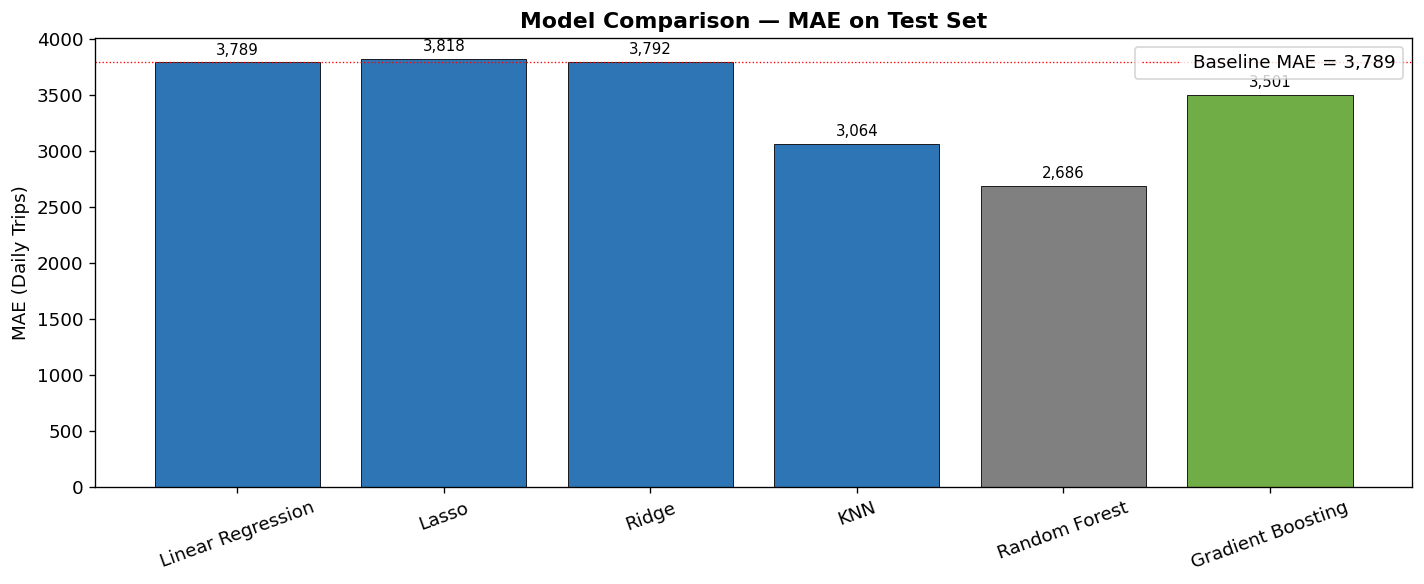

Saved: fig_model_comparison.png


In [ ]:
# to see individually how each model performed, we will create a bar chart comparing the MAE of each model on the test set.
raw_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [BLUE]*4 + ['#808080'] + ['#70AD47','#C00000']
bars = ax.bar(raw_results['name'], raw_results['mae'],
               color=colors_bar, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Model Comparison — MAE on Test Set', fontweight='bold')
ax.set_ylabel('MAE (Daily Trips)')
ax.tick_params(axis='x', rotation=20)

# Baseline reference line - linear regression MAE  
baseline_mae = raw_results.loc[raw_results['name']=='Linear Regression','mae'].values[0]
ax.axhline(baseline_mae, color='red', linestyle=':', linewidth=0.8, label=f'Baseline MAE = {baseline_mae:,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_model_comparison.png')

In [ ]:
colors_bar = [BLUE]*4 + ['#808080'] + ['#70AD47','#C00000']
bars = ax.bar(raw_results['name'], raw_results['mae'],
               color=colors_bar, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Model Comparison — MAE on Test Set', fontweight='bold')
ax.set_ylabel('MAE (Daily Trips)')
ax.tick_params(axis='x', rotation=20)

# Baseline reference line - linear regression MAE  
baseline_mae = raw_results.loc[raw_results['name']=='Linear Regression','mae'].values[0]
ax.axhline(baseline_mae, color='red', linestyle=':', linewidth=0.8, label=f'Baseline MAE = {baseline_mae:,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_model_comparison.png')

In [23]:
# to make more interpretable business insights
# we will apply random forest to compute a 95% confidence interval 
# for the MAE of the best model
np.random.seed(42)
N_BOOTSTRAP = 1000
boot_maes = []

for _ in range(N_BOOTSTRAP):
    idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
    boot_maes.append(mean_absolute_error(y_test[idx], rf_pred[idx]))

boot_maes = np.array(boot_maes)

ci_lower = np.percentile(boot_maes, 2.5)
ci_upper = np.percentile(boot_maes, 97.5)
ci_mean  = np.mean(boot_maes)

print(f'Bootstrap MAE (Random Forest, n={N_BOOTSTRAP:,} resamples)')
print(f'  Mean : {ci_mean:>8,.1f}')
print(f'  95% CI: [{ci_lower:,.1f}  ,  {ci_upper:,.1f}]')
print()

print('Business interpretation:')
print(f'  The model average daily error is {ci_mean:,.0f} trips.')
print(f'  With 95% confidence, the true MAE lies between {ci_lower:,.0f} and {ci_upper:,.0f} trips/day.')
print(f'  Recommended safety buffer ≈ {ci_upper:,.0f} bikes to cover worst-case typical error.')

Bootstrap MAE (Random Forest, n=1,000 resamples)
  Mean :  2,684.2
  95% CI: [2,393.1  ,  3,015.5]

Business interpretation:
  The model average daily error is 2,684 trips.
  With 95% confidence, the true MAE lies between 2,393 and 3,015 trips/day.
  Recommended safety buffer ≈ 3,015 bikes to cover worst-case typical error.


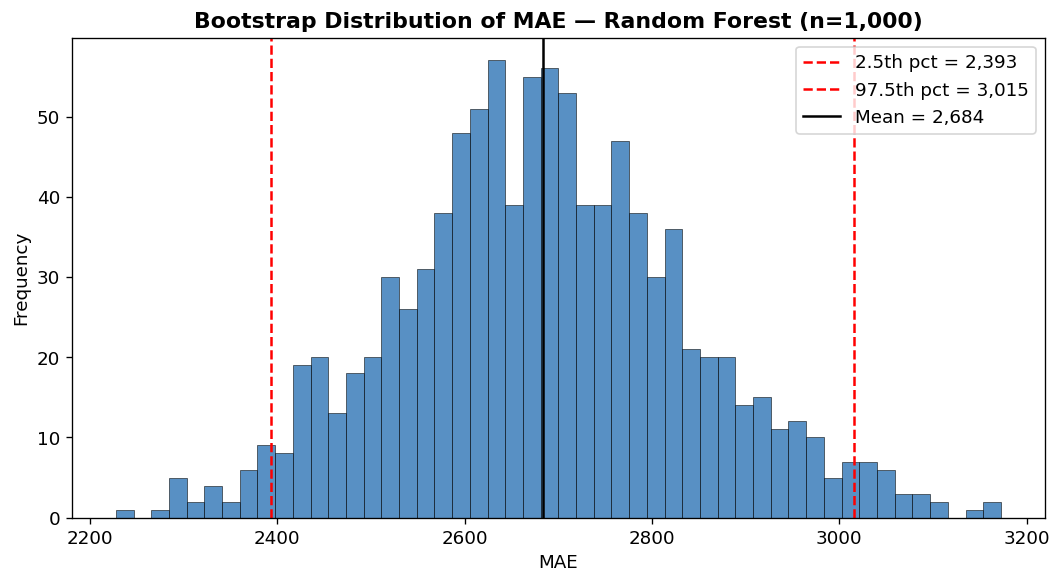

Saved: fig_bootstrap_ci_rf.png


In [24]:
# and finally, we will plot the random forest-bootstrap distribution of MAE to visualize the variability and confidence interval.
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(boot_maes, bins=50, color=BLUE, edgecolor='black', linewidth=0.4, alpha=0.8)

ax.axvline(ci_lower, color='red', linestyle='--', linewidth=1.5,
           label=f'2.5th pct = {ci_lower:,.0f}')
ax.axvline(ci_upper, color='red', linestyle='--', linewidth=1.5,
           label=f'97.5th pct = {ci_upper:,.0f}')
ax.axvline(ci_mean, color='black', linestyle='-', linewidth=1.5,
           label=f'Mean = {ci_mean:,.0f}')

ax.set_title('Bootstrap Distribution of MAE — Random Forest (n=1,000)', fontweight='bold')
ax.set_xlabel('MAE')
ax.set_ylabel('Frequency')

ax.legend()
plt.tight_layout()

plt.savefig('fig_bootstrap_ci_rf.png', bbox_inches='tight', dpi=150)
plt.show()

print('Saved: fig_bootstrap_ci_rf.png')